In [4]:
topology_list = ["dring","ls","rrg","df"]
data_dict = {
    "dring": [1066, 1292, 802],
    "ls": [0, 2016, 0],
    "rrg": [1024, 2136, 0],
    "df": [780, 1824, 399]
}

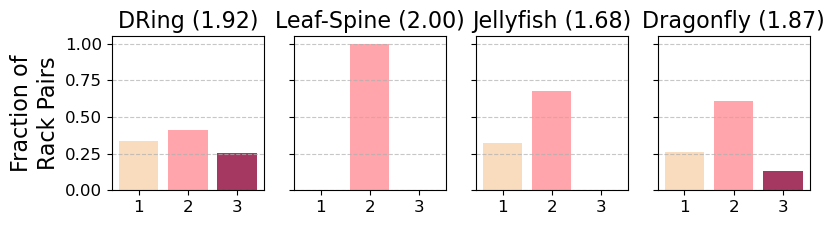

In [79]:
import matplotlib.pyplot as plt
import numpy as np

plottitle_dict = {"dring": "DRing", "ls": "Leaf-Spine", "rrg": "Jellyfish", "df": "Dragonfly"}

# Path lengths
path_lengths = [1, 2, 3]

# Set up the figure with 4 subplots in one row
fig, axes = plt.subplots(1, 4, figsize=(9, 2), sharey=True)

# Loop through each topology and plot
for ax, (topology, counts) in zip(axes, data_dict.items()):
    total = sum(counts)
    fractions = [count / total for count in counts]
    avg_length = sum(p * c for p, c in zip(path_lengths, counts)) / total
    ax.bar(path_lengths, fractions, color=['#f9dbbd', '#ffa5ab', '#a53860'])
    ax.set_title(f"{plottitle_dict[topology]} ({avg_length:.2f})",fontsize=16)
    ax.set_xticks(path_lengths)
    # ax.set_xlabel("Shortest Path Length",fontsize=16)
    ax.set_ylim(0, 1.05)
    ax.set_yticks([0, 0.25, 0.5, 0.75, 1.0])
    ax.tick_params(axis='both', labelsize=12)
    ax.grid(axis='y', linestyle='--', alpha=0.7)
    if ax == axes[0]:
        ax.set_ylabel("Fraction of\nRack Pairs",fontsize=16)

# Add overall title and layout adjustment
# fig.suptitle("Shortest Path Length Distribution per Topology", fontsize=14)
# plt.tight_layout(rect=[0, 0.03, 1, 0.95])
# plt.show()
plt.savefig(f"design_minpath.pdf", dpi=600, bbox_inches='tight')

In [2]:
numsw = 80
graphfile_list = ["dring_80_64.edgelist","rrg_80_64.edgelist","df_p40_a2_h19.edgelist"]

In [3]:
import pickle

# Load data
with open('num_path.pkl', 'rb') as f:
    datadict = pickle.load(f)

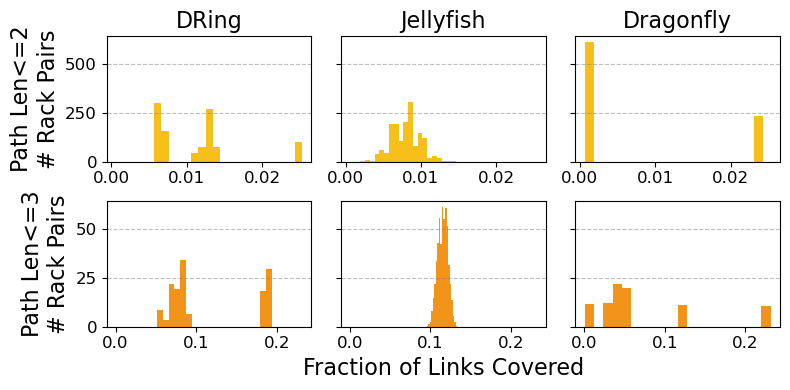

In [83]:
import matplotlib.pyplot as plt

plottitle_dict = {"dring_80_64.edgelist": "DRing", "ls": "Leaf-Spine", "rrg_80_64.edgelist": "Jellyfish", "df_p40_a2_h19.edgelist": "Dragonfly"}
# color_list = ['#f9dbbd', '#ffa5ab', '#a53860']
color_list = ["#f7b801","#f7b801","#f18701"]

# Total number of links per topology
total_links_dict = {
    'dring_80_64.edgelist': 2132,
    'rrg_80_64.edgelist': 2048,
    'df_p40_a2_h19.edgelist': 1560
}

# Setup figure with 2 rows (K=2 and K=3) and 3 columns (topologies)
fig, axes = plt.subplots(2, 3, figsize=(8, 4), sharex='row', sharey='row')

Ks = [2, 3]
k_indices = [1, 2]  # index 1 for ≤2, index 2 for ≤3

for row, k_index in enumerate(k_indices):
    for col, (topo_name, pair_links_list) in enumerate(datadict.items()):
        ax = axes[row, col]
        total_links = total_links_dict[topo_name]
        pair_links = pair_links_list[k_index]

        coverage_vals = [
            len(links_used) / total_links
            for (i, j), links_used in pair_links.items()
        ]

        ax.hist(coverage_vals, bins=20, density=True, alpha=0.9, color=color_list[k_index])
        if row==0:
            ax.set_title(f"{plottitle_dict[topo_name]}",fontsize=16)
        elif row == 1:
            if col==1:
                ax.set_xlabel("Fraction of Links Covered", fontsize=16)
        
        if col == 0:
            ax.set_ylabel(f"Path Len<={k_index+1}\n# Rack Pairs", fontsize=16)

        ax.grid(axis='y', color='gray', linestyle='--', alpha=0.5)
        # ax.set_xticks([0, 25, 50, 75, 100])
        # ax.set_yticks([0, 5, 10, 15, 20])
        ax.tick_params(axis='both', labelsize=12)

# fig.suptitle("Histogram of Link Coverage per Router Pair", fontsize=16)
plt.tight_layout()
plt.savefig(f"design_numpath.pdf", dpi=600, bbox_inches='tight')
# plt.show()


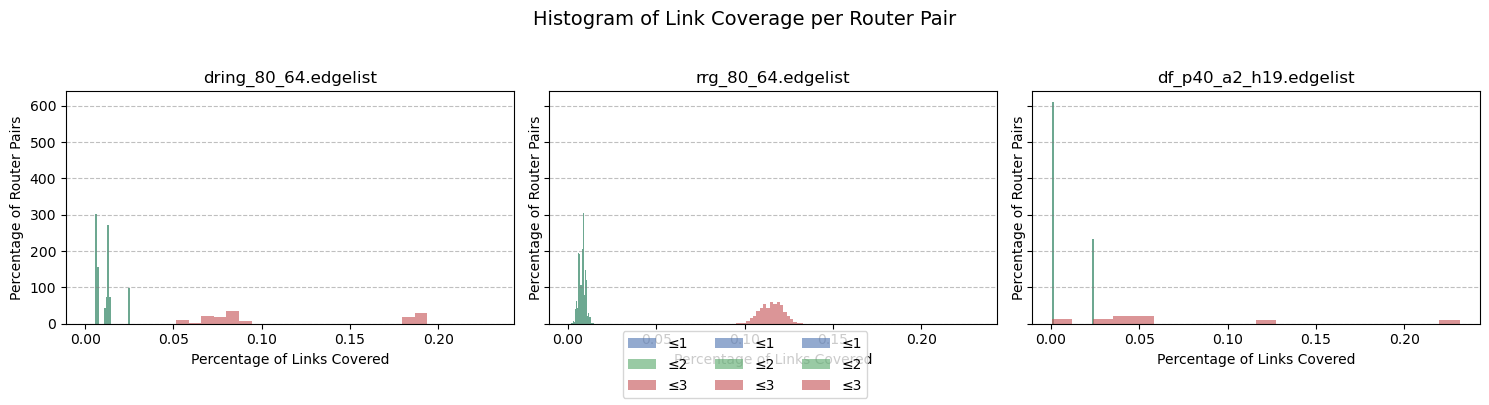

In [45]:
import matplotlib.pyplot as plt
import numpy as np
import pickle

# Load the data
with open('num_path.pkl', 'rb') as f:
    datadict = pickle.load(f)

# Total number of links per topology
total_links_dict = {
    'dring_80_64.edgelist': 2132,
    'rrg_80_64.edgelist': 2048,
    'df_p40_a2_h19.edgelist': 1560
}


fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharex=True,sharey=True)
Ks = [1, 2, 3]
colors = ['#4c72b0', '#55a868', '#c44e52']

for ax, (topo_name, pair_links_list) in zip(axes, datadict.items()):
    total_links = total_links_dict[topo_name]

    for k_idx, pair_links in enumerate(pair_links_list):
        coverage_vals = [
            len(links_used) / total_links
            for (i, j), links_used in pair_links.items()
        ]
        ax.hist(coverage_vals, bins=20, density=True, alpha=0.6,
                label=f'≤{Ks[k_idx]}', color=colors[k_idx])
    
    ax.set_title(topo_name)
    ax.set_xlabel("Percentage of Links Covered")
    ax.grid(axis='y', color='gray', linestyle='--', alpha=0.5)
    ax.tick_params(axis='both', labelsize=10)
    # ax.set_xticks([0, 25, 50, 75, 100])
    # ax.set_yticks([0, 5, 10, 15, 20])
    ax.set_ylabel("Percentage of Router Pairs")

fig.suptitle("Histogram of Link Coverage per Router Pair", fontsize=14)
fig.legend(loc='lower center', ncol=3)
plt.tight_layout(rect=[0, 0.05, 1, 0.95])
# plt.savefig("link_coverage_histogram.pdf", format="pdf")


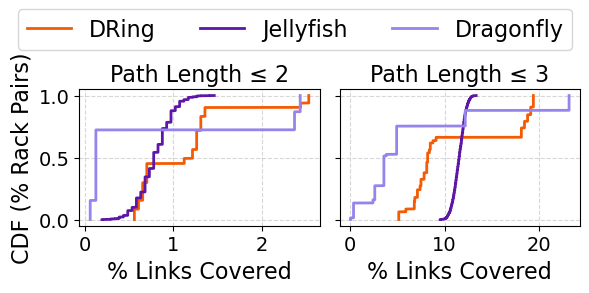

In [8]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42

plottitle_dict = {
    "dring_80_64.edgelist": "DRing",
    "rrg_80_64.edgelist": "Jellyfish",
    "df_p40_a2_h19.edgelist": "Dragonfly"
}

# One color per topology
color_dict = {
    "dring_80_64.edgelist": "#f35b04",
    "rrg_80_64.edgelist": "#5d16a6",
    "df_p40_a2_h19.edgelist": "#9683ec"
}

# Total number of links per topology
total_links_dict = {
    "dring_80_64.edgelist": 2132,
    "rrg_80_64.edgelist": 2048,
    "df_p40_a2_h19.edgelist": 1560
}

# Two subplots: one for <=2, one for <=3
fig, axes = plt.subplots(1, 2, figsize=(6, 2.5), sharey=True)

k_indices = [1, 2]   # index 1 -> <=2, index 2 -> <=3
k_labels = ["Path Length ≤ 2", "Path Length ≤ 3"]

for ax, k_index, k_label in zip(axes, k_indices, k_labels):
    for topo_name in ["dring_80_64.edgelist", "rrg_80_64.edgelist", "df_p40_a2_h19.edgelist"]:
        pair_links_list = datadict[topo_name]
        total_links = total_links_dict[topo_name]
        pair_links = pair_links_list[k_index]

        coverage_vals = np.array([
            len(links_used) / total_links
            for (i, j), links_used in pair_links.items()
        ])

        # Sort values for empirical CDF
        x = np.sort(coverage_vals) * 100   # convert fraction -> percentage
        y = np.arange(1, len(x) + 1) / len(x)

        if k_index == 1:
            ax.plot(
                x, y,
                label=plottitle_dict[topo_name],
                color=color_dict[topo_name],
                linewidth=2
            )
        else:
            ax.plot(
                x, y,
                color=color_dict[topo_name],
                linewidth=2
            )

    ax.set_title(k_label, fontsize=16)
    ax.set_xlabel("% Links Covered", fontsize=16)
    ax.grid(True, linestyle="--", alpha=0.5)
    ax.tick_params(axis='both', labelsize=14)

axes[0].set_ylabel("CDF (% Rack Pairs)", fontsize=16)
fig.legend(loc='upper center', bbox_to_anchor=(0.5, 1.2), ncol=3, fontsize=16)

plt.tight_layout()
plt.savefig("design_numpath_cdf.pdf", dpi=600, bbox_inches="tight")
# plt.show()